# Práctica: Extracciones de datos y modelos de Machine Learning

**Materia:** Tópicos de Big Data
**Actividad:** Ejercicios de extracciones / Modelos ML
**Modelos:** Regresión Lineal (RL) · Regresión Polinomial (RP) · Random Forest (RF)

---

### Instrucciones

Utilizando el notebook de los 3 modelos (RL, RP, RF), realizar los siguientes ejercicios y graficar los resultados de los modelos:

1. Extraer el país de **China**
2. Extraer nacimientos / defunciones **a partir de 1980** en **México**
3. Extraer nacimientos / defunciones **a partir de 2000** en **México**

En este notebook se copiaron las celdas de la práctica original y se replicó el procedimiento para cada extracción.

## Importar bibliotecas

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

## Cargar el dataset de Our World in Data

In [70]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## Renombrar columnas y unificar datos históricos + proyecciones

In [71]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


## Años a proyectar (2024–2100)

Se usan para las tres extracciones.

In [72]:
anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

X_futuro.head()

,Year
0,2024
1,2025
2,2026
3,2027
4,2028


---
# EJERCICIO 1. Extraer el país de China

## 1.1 Extracción

In [73]:
pais = "China"

df_china = df[df["Entity"] == pais]

df_china.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


In [74]:
print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

Rango de años: 1950 - 2100
Número de filas: 151


## 1.2 Exploración visual

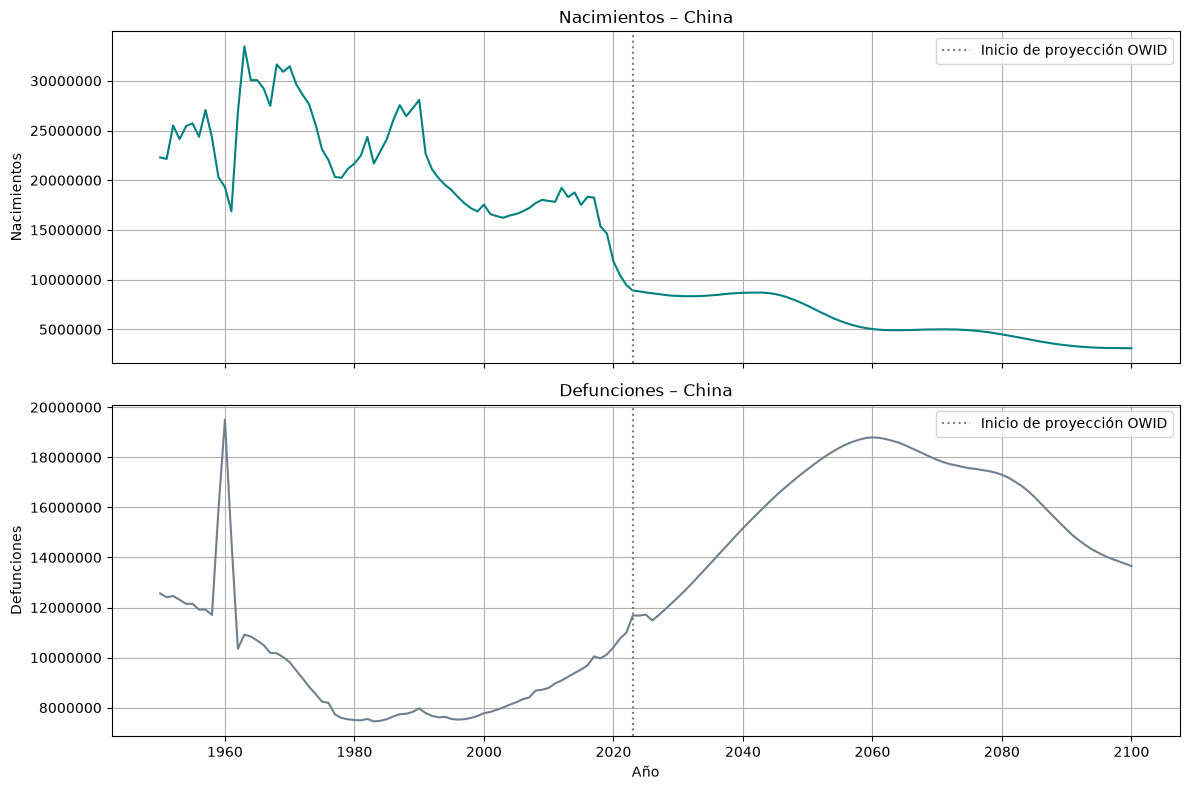

In [75]:
fig, ejes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ejes[0].plot(df_china["Year"], df_china["births"], color="teal")
ejes[0].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[0].set_title("Nacimientos – China")
ejes[0].set_ylabel("Nacimientos")
ejes[0].legend()
ejes[0].grid()

ejes[1].plot(df_china["Year"], df_china["deaths"], color="slategray")
ejes[1].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[1].set_title("Defunciones – China")
ejes[1].set_xlabel("Año")
ejes[1].set_ylabel("Defunciones")
ejes[1].legend()
ejes[1].grid()

for eje in ejes:
    eje.ticklabel_format(style="plain", axis="y", useOffset=False)

plt.tight_layout()
plt.show()

## 1.3 Separar datos históricos (≤ 2023) y proyectados (> 2023)

In [76]:
historico_china = df_china[df_china["Year"] <= 2023]
proyectado_china = df_china[df_china["Year"] > 2023]

print("Histórico  ->", historico_china.shape, "| años:", historico_china["Year"].min(), "a", historico_china["Year"].max())
print("Proyectado ->", proyectado_china.shape, "| años:", proyectado_china["Year"].min(), "a", proyectado_china["Year"].max())

Histórico  -> (74, 9) | años: 1950 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


## 1.4 Variables X e y

In [77]:
X_china = historico_china[["Year"]]
y_nac_china = historico_china["births"]
y_def_china = historico_china["deaths"]

print("X:", X_china.shape, "| y:", y_nac_china.shape)

X: (74, 1) | y: (74,)


## 1.5 Modelos para **nacimientos**

### Regresión lineal

In [78]:
rl_nac_china = LinearRegression()
rl_nac_china.fit(X_china, y_nac_china)

print("Pendiente (a):", rl_nac_china.coef_[0])
print("Intercepto (b):", rl_nac_china.intercept_)

pred_rl_nac_china = rl_nac_china.predict(X_china)
fut_rl_nac_china = rl_nac_china.predict(X_futuro)

Pendiente (a): -187208.31004813028
Intercepto (b): 393489519.9376378


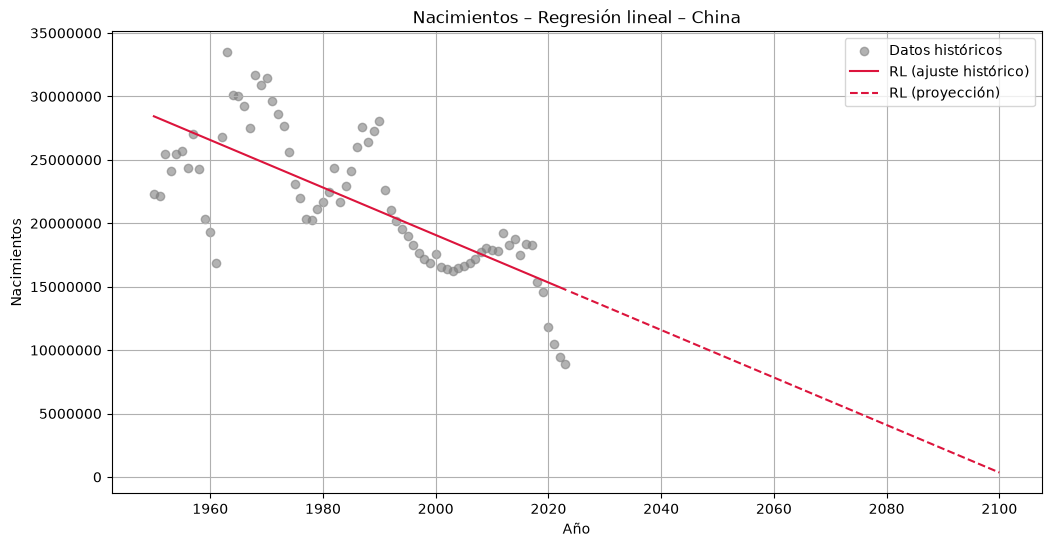

In [79]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_nac_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rl_nac_china, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_nac_china, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Nacimientos – Regresión lineal – China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [80]:
poly_nac_china = PolynomialFeatures(degree=2, include_bias=False)
X_poly_nac_china = poly_nac_china.fit_transform(X_china)

rp_nac_china = LinearRegression()
rp_nac_china.fit(X_poly_nac_china, y_nac_china)

pred_rp_nac_china = rp_nac_china.predict(X_poly_nac_china)
fut_rp_nac_china = rp_nac_china.predict(poly_nac_china.transform(X_futuro))

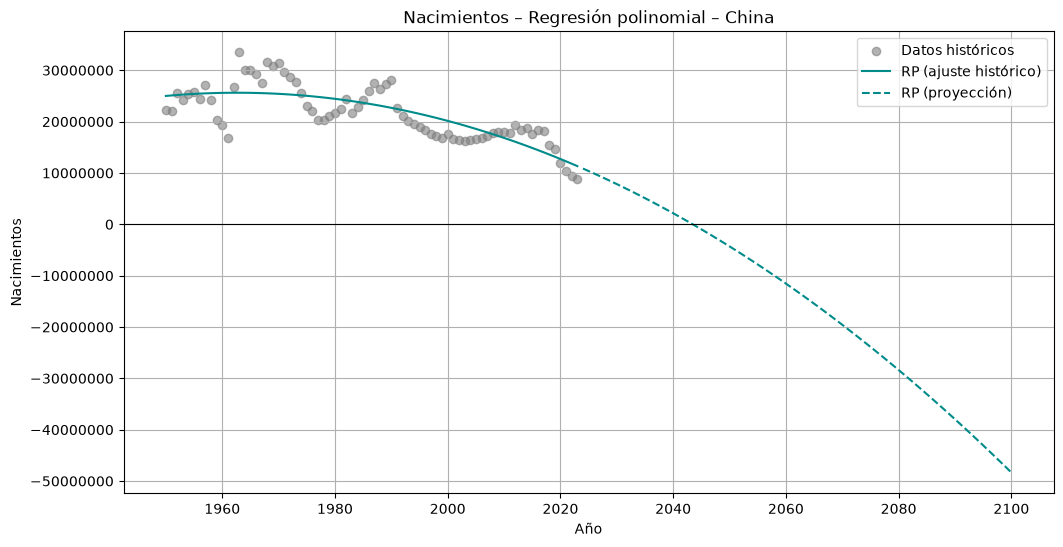

In [81]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_nac_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rp_nac_china, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_nac_china, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Nacimientos – Regresión polinomial – China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [82]:
rf_nac_china = RandomForestRegressor(n_estimators=100, random_state=42)
rf_nac_china.fit(X_china, y_nac_china)

pred_rf_nac_china = rf_nac_china.predict(X_china)
fut_rf_nac_china = rf_nac_china.predict(X_futuro)

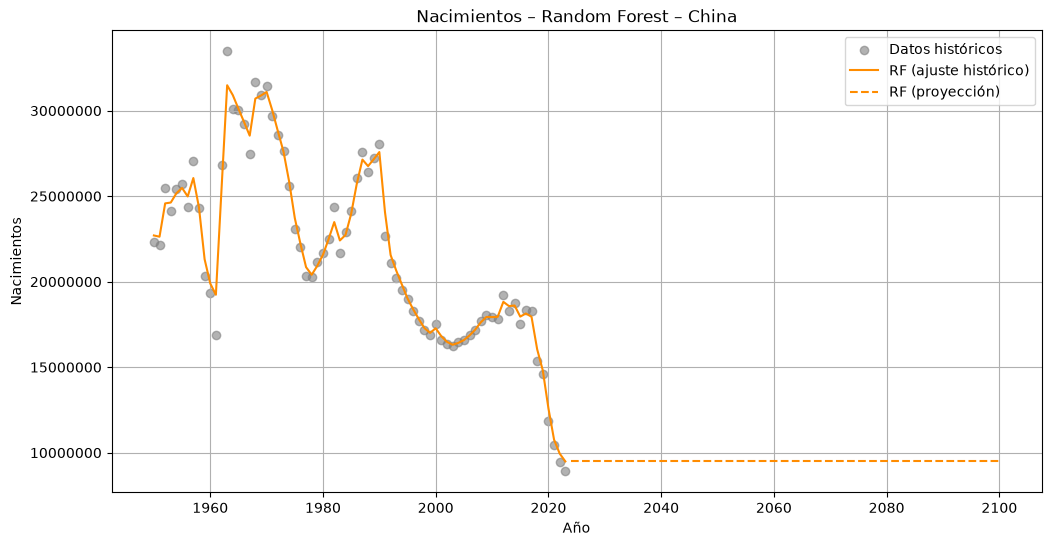

In [83]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_nac_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rf_nac_china, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_nac_china, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Nacimientos – Random Forest – China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (nacimientos)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

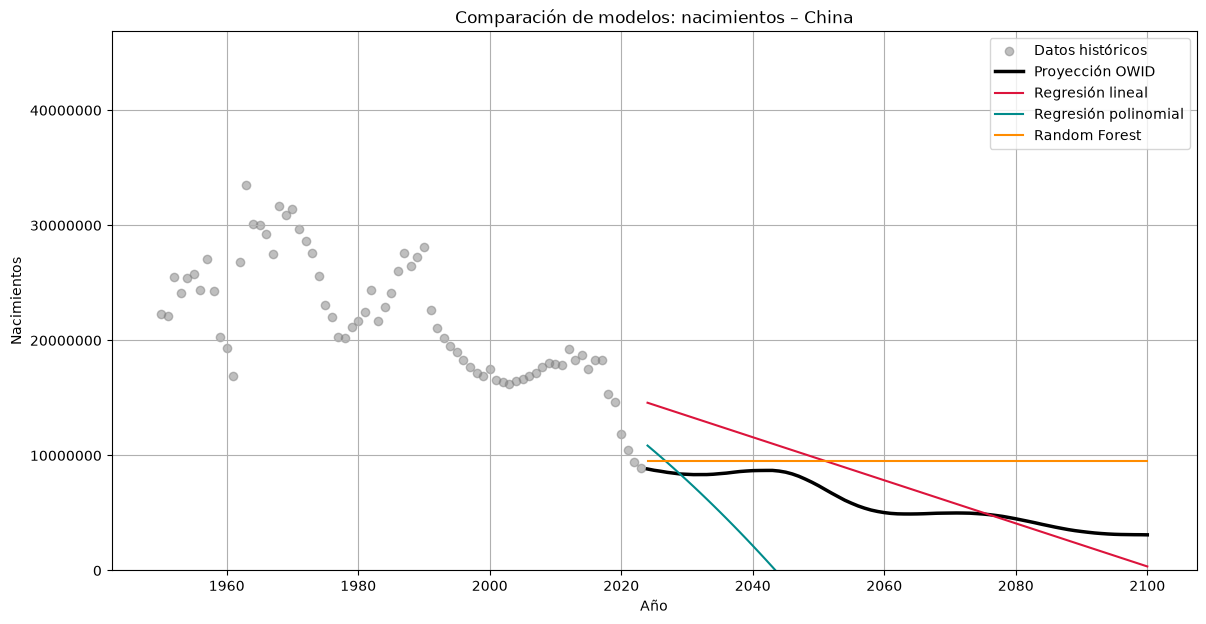

In [84]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_china["Year"], y_nac_china, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_china["Year"], proyectado_china["births"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_nac_china, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_nac_china, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_nac_china, color="darkorange", label="Random Forest")

limite = max(y_nac_china.max(), proyectado_china["births"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: nacimientos – China")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 1.6 Modelos para **defunciones**

### Regresión lineal

In [85]:
rl_def_china = LinearRegression()
rl_def_china.fit(X_china, y_def_china)

print("Pendiente (a):", rl_def_china.coef_[0])
print("Intercepto (b):", rl_def_china.intercept_)

pred_rl_def_china = rl_def_china.predict(X_china)
fut_rl_def_china = rl_def_china.predict(X_futuro)

Pendiente (a): -45906.09784524248
Intercepto (b): 100675077.57227689


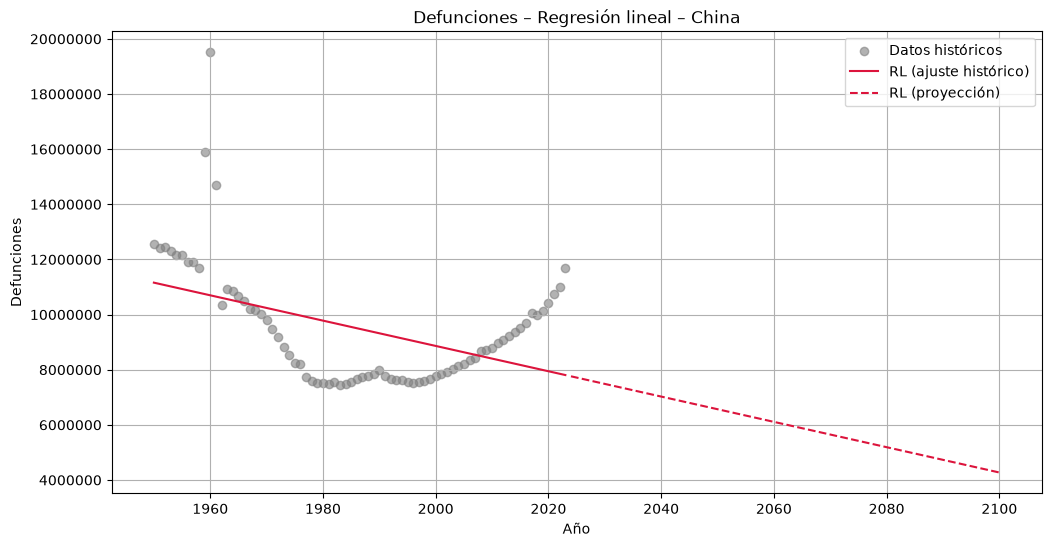

In [86]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_def_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rl_def_china, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_def_china, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Defunciones – Regresión lineal – China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [87]:
poly_def_china = PolynomialFeatures(degree=2, include_bias=False)
X_poly_def_china = poly_def_china.fit_transform(X_china)

rp_def_china = LinearRegression()
rp_def_china.fit(X_poly_def_china, y_def_china)

pred_rp_def_china = rp_def_china.predict(X_poly_def_china)
fut_rp_def_china = rp_def_china.predict(poly_def_china.transform(X_futuro))

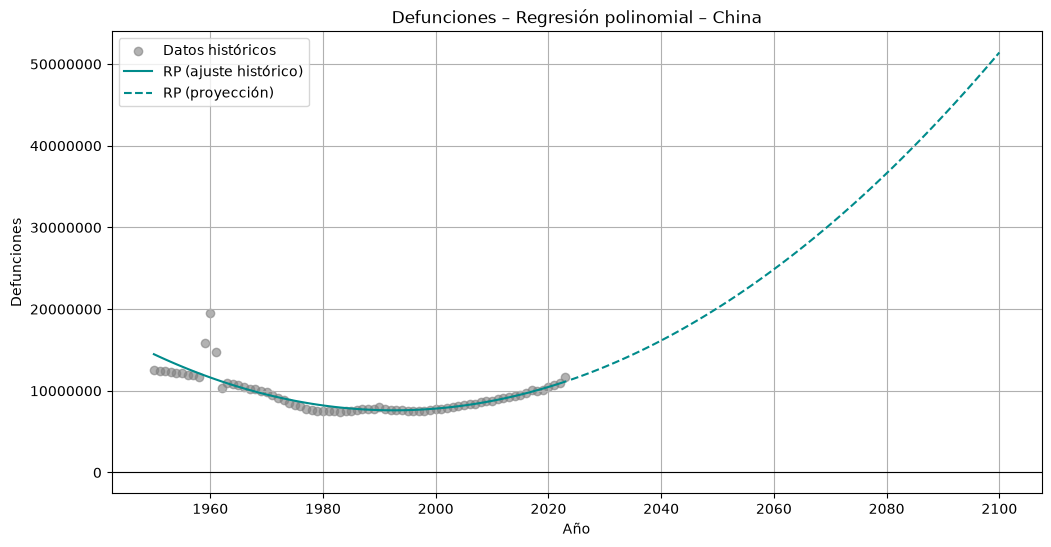

In [88]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_def_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rp_def_china, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_def_china, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Defunciones – Regresión polinomial – China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [89]:
rf_def_china = RandomForestRegressor(n_estimators=100, random_state=42)
rf_def_china.fit(X_china, y_def_china)

pred_rf_def_china = rf_def_china.predict(X_china)
fut_rf_def_china = rf_def_china.predict(X_futuro)

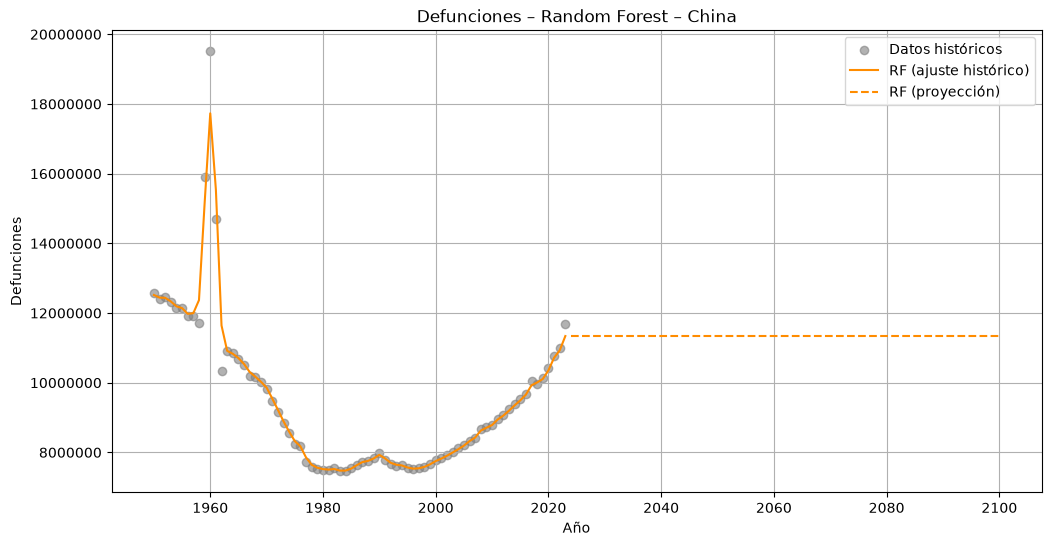

In [90]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_china["Year"], y_def_china, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_china["Year"], pred_rf_def_china, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_def_china, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Defunciones – Random Forest – China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (defunciones)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

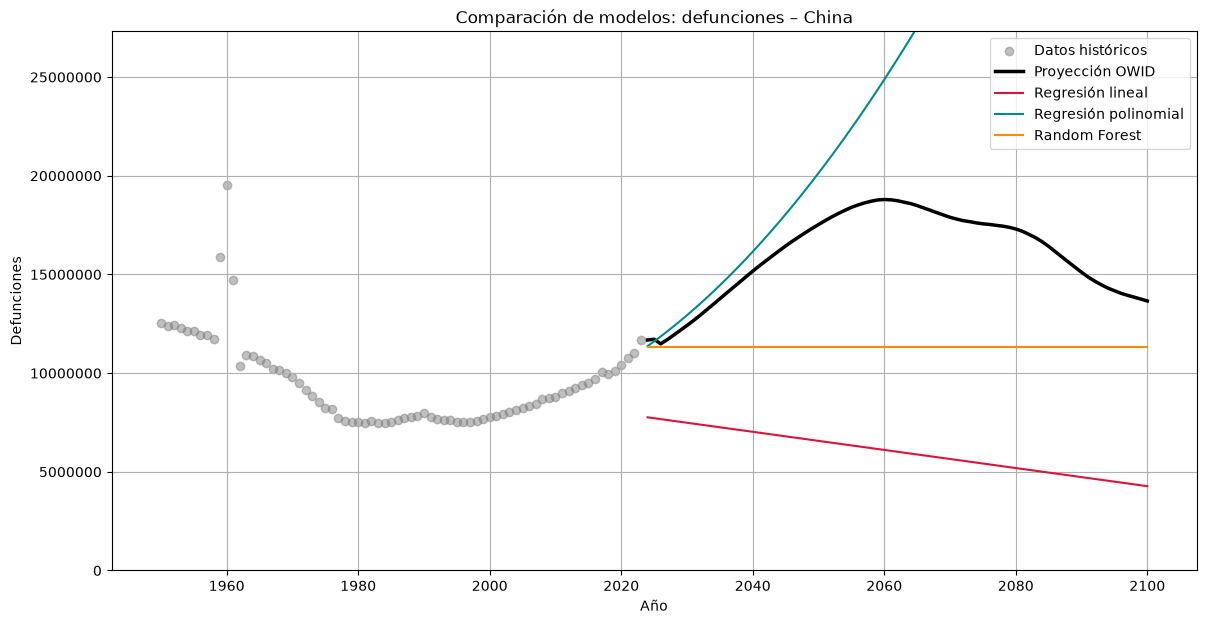

In [91]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_china["Year"], y_def_china, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_china["Year"], proyectado_china["deaths"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_def_china, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_def_china, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_def_china, color="darkorange", label="Random Forest")

limite = max(y_def_china.max(), proyectado_china["deaths"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: defunciones – China")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---
# EJERCICIO 2. México: nacimientos / defunciones a partir de 1980

## 2.1 Extracción

In [92]:
pais = "Mexico"

df_mx80 = df[(df["Entity"] == pais) & (df["Year"] >= 1980)]

df_mx80.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22831,Mexico,MEX,1980,464115.0,NaN,2357249.0,NaN,2357249.0,464115.0
22832,Mexico,MEX,1981,461670.0,NaN,2366047.0,NaN,2366047.0,461670.0
22833,Mexico,MEX,1982,462853.0,NaN,2384613.0,NaN,2384613.0,462853.0
22834,Mexico,MEX,1983,465775.0,NaN,2404958.0,NaN,2404958.0,465775.0
22835,Mexico,MEX,1984,470587.0,NaN,2431036.0,NaN,2431036.0,470587.0


In [93]:
print("Rango de años:", df_mx80["Year"].min(), "-", df_mx80["Year"].max())
print("Número de filas:", df_mx80.shape[0])

Rango de años: 1980 - 2100
Número de filas: 121


## 2.2 Exploración visual

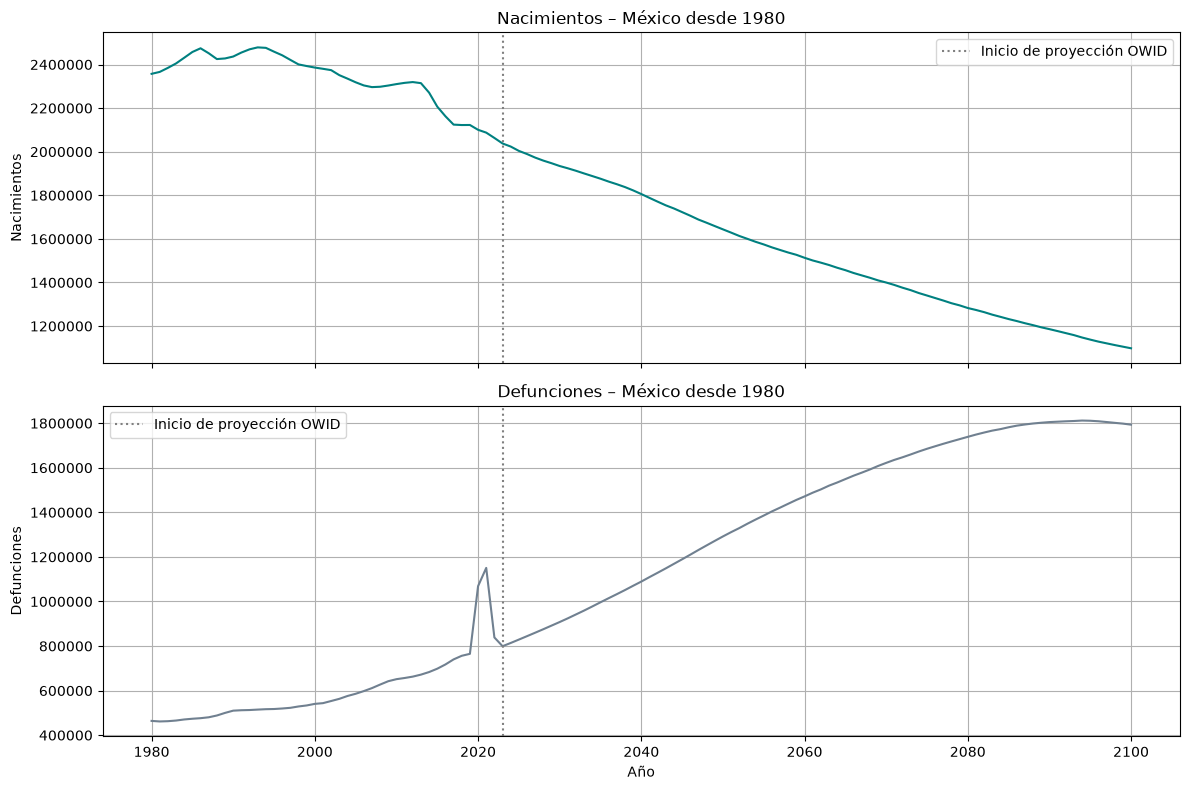

In [94]:
fig, ejes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ejes[0].plot(df_mx80["Year"], df_mx80["births"], color="teal")
ejes[0].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[0].set_title("Nacimientos – México desde 1980")
ejes[0].set_ylabel("Nacimientos")
ejes[0].legend()
ejes[0].grid()

ejes[1].plot(df_mx80["Year"], df_mx80["deaths"], color="slategray")
ejes[1].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[1].set_title("Defunciones – México desde 1980")
ejes[1].set_xlabel("Año")
ejes[1].set_ylabel("Defunciones")
ejes[1].legend()
ejes[1].grid()

for eje in ejes:
    eje.ticklabel_format(style="plain", axis="y", useOffset=False)

plt.tight_layout()
plt.show()

## 2.3 Separar datos históricos (≤ 2023) y proyectados (> 2023)

In [95]:
historico_mx80 = df_mx80[df_mx80["Year"] <= 2023]
proyectado_mx80 = df_mx80[df_mx80["Year"] > 2023]

print("Histórico  ->", historico_mx80.shape, "| años:", historico_mx80["Year"].min(), "a", historico_mx80["Year"].max())
print("Proyectado ->", proyectado_mx80.shape, "| años:", proyectado_mx80["Year"].min(), "a", proyectado_mx80["Year"].max())

Histórico  -> (44, 9) | años: 1980 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


## 2.4 Variables X e y

In [96]:
X_mx80 = historico_mx80[["Year"]]
y_nac_mx80 = historico_mx80["births"]
y_def_mx80 = historico_mx80["deaths"]

print("X:", X_mx80.shape, "| y:", y_nac_mx80.shape)

X: (44, 1) | y: (44,)


## 2.5 Modelos para **nacimientos**

### Regresión lineal

In [97]:
rl_nac_mx80 = LinearRegression()
rl_nac_mx80.fit(X_mx80, y_nac_mx80)

print("Pendiente (a):", rl_nac_mx80.coef_[0])
print("Intercepto (b):", rl_nac_mx80.intercept_)

pred_rl_nac_mx80 = rl_nac_mx80.predict(X_mx80)
fut_rl_nac_mx80 = rl_nac_mx80.predict(X_futuro)

Pendiente (a): -8434.048273431994
Intercepto (b): 19210679.005637772


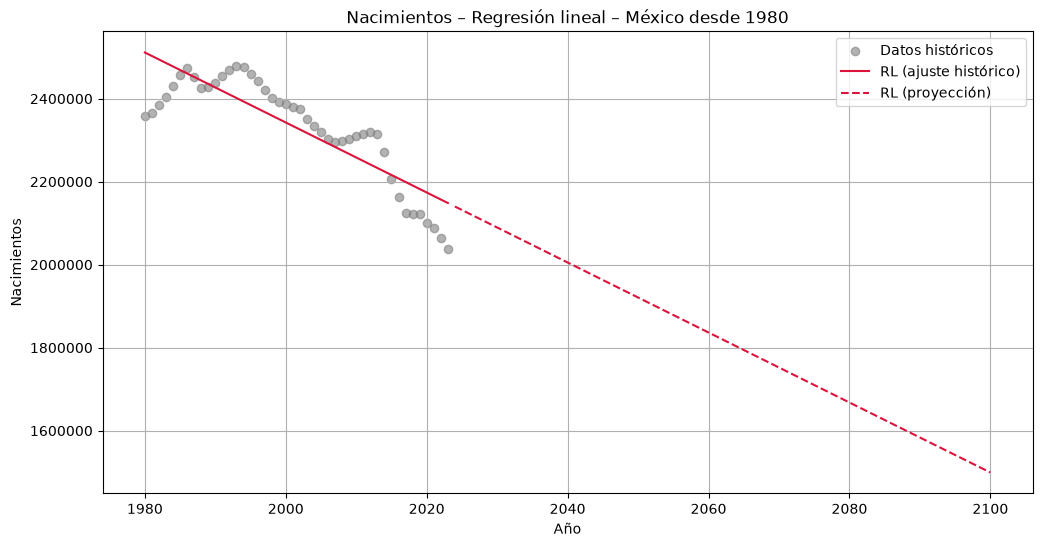

In [98]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_nac_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rl_nac_mx80, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_nac_mx80, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Nacimientos – Regresión lineal – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [99]:
poly_nac_mx80 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_nac_mx80 = poly_nac_mx80.fit_transform(X_mx80)

rp_nac_mx80 = LinearRegression()
rp_nac_mx80.fit(X_poly_nac_mx80, y_nac_mx80)

pred_rp_nac_mx80 = rp_nac_mx80.predict(X_poly_nac_mx80)
fut_rp_nac_mx80 = rp_nac_mx80.predict(poly_nac_mx80.transform(X_futuro))

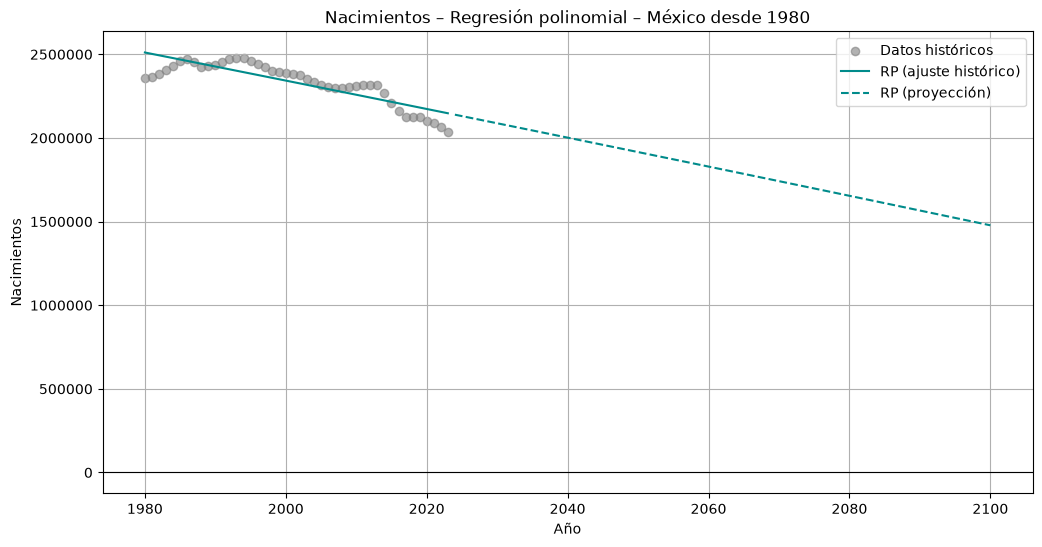

In [100]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_nac_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rp_nac_mx80, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_nac_mx80, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Nacimientos – Regresión polinomial – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [101]:
rf_nac_mx80 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_nac_mx80.fit(X_mx80, y_nac_mx80)

pred_rf_nac_mx80 = rf_nac_mx80.predict(X_mx80)
fut_rf_nac_mx80 = rf_nac_mx80.predict(X_futuro)

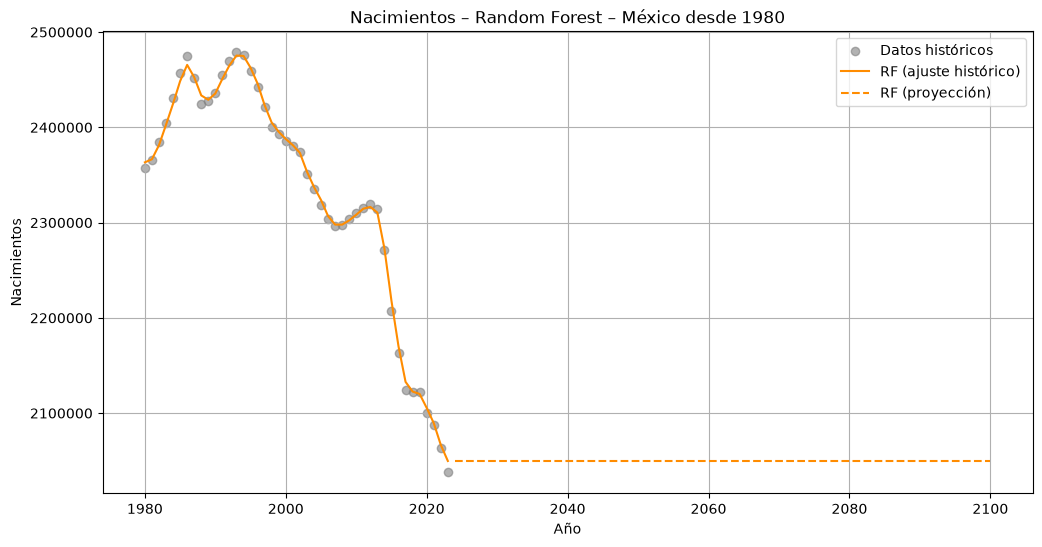

In [102]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_nac_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rf_nac_mx80, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_nac_mx80, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Nacimientos – Random Forest – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (nacimientos)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

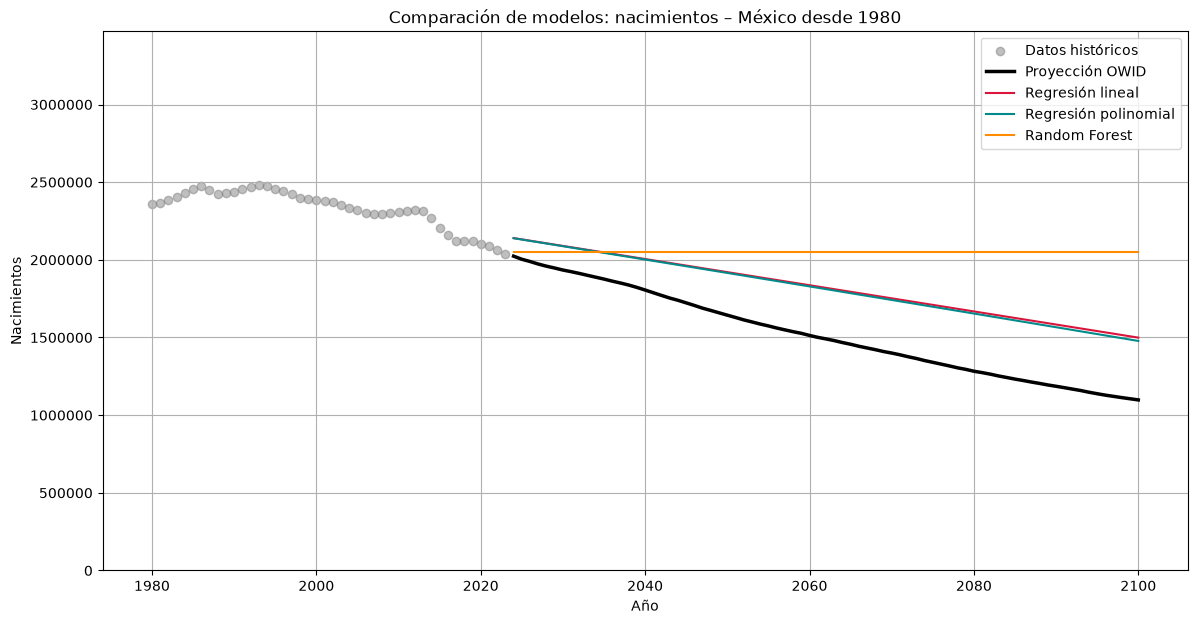

In [103]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_mx80["Year"], y_nac_mx80, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_mx80["Year"], proyectado_mx80["births"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_nac_mx80, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_nac_mx80, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_nac_mx80, color="darkorange", label="Random Forest")

limite = max(y_nac_mx80.max(), proyectado_mx80["births"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: nacimientos – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 2.6 Modelos para **defunciones**

### Regresión lineal

In [104]:
rl_def_mx80 = LinearRegression()
rl_def_mx80.fit(X_mx80, y_def_mx80)

print("Pendiente (a):", rl_def_mx80.coef_[0])
print("Intercepto (b):", rl_def_mx80.intercept_)

pred_rl_def_mx80 = rl_def_mx80.predict(X_mx80)
fut_rl_def_mx80 = rl_def_mx80.predict(X_futuro)

Pendiente (a): 9975.8407329105
Intercepto (b): -19361301.09055673


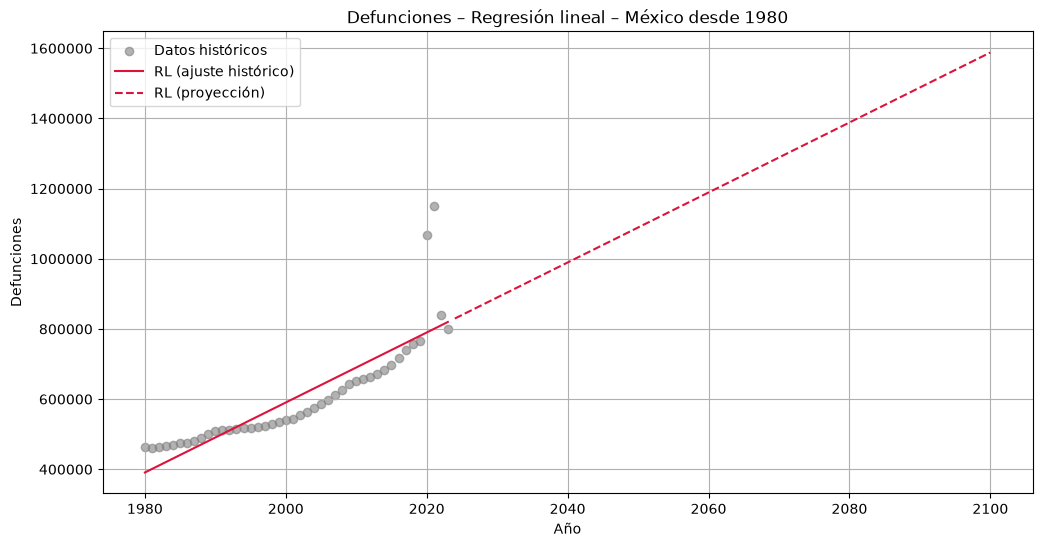

In [105]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_def_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rl_def_mx80, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_def_mx80, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Defunciones – Regresión lineal – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [106]:
poly_def_mx80 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_def_mx80 = poly_def_mx80.fit_transform(X_mx80)

rp_def_mx80 = LinearRegression()
rp_def_mx80.fit(X_poly_def_mx80, y_def_mx80)

pred_rp_def_mx80 = rp_def_mx80.predict(X_poly_def_mx80)
fut_rp_def_mx80 = rp_def_mx80.predict(poly_def_mx80.transform(X_futuro))

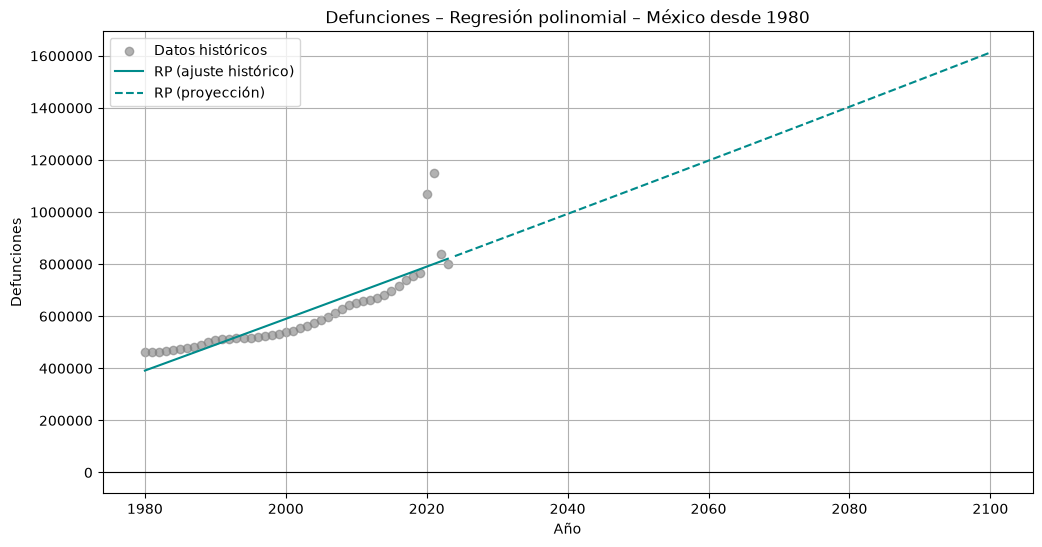

In [107]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_def_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rp_def_mx80, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_def_mx80, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Defunciones – Regresión polinomial – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [108]:
rf_def_mx80 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_def_mx80.fit(X_mx80, y_def_mx80)

pred_rf_def_mx80 = rf_def_mx80.predict(X_mx80)
fut_rf_def_mx80 = rf_def_mx80.predict(X_futuro)

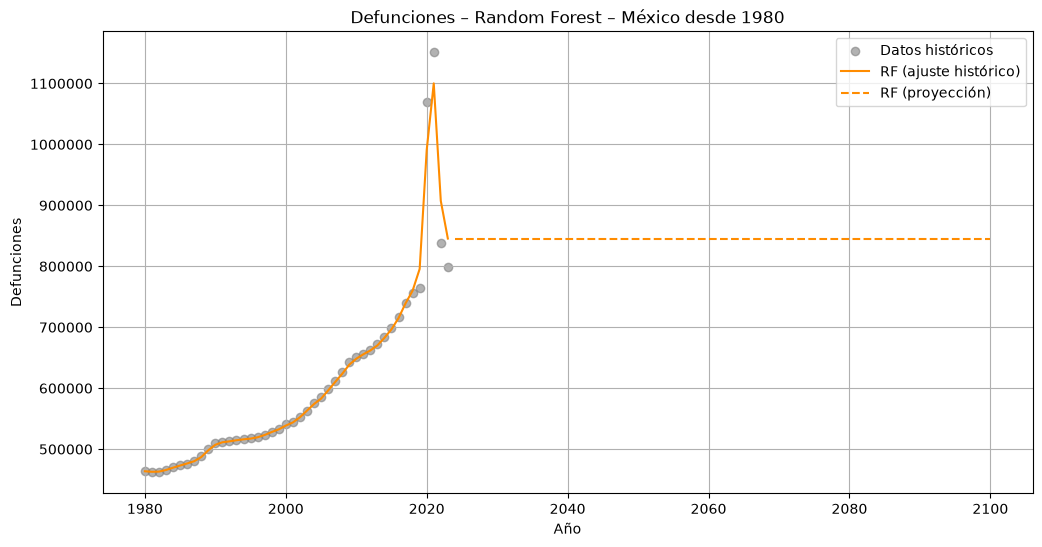

In [109]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx80["Year"], y_def_mx80, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx80["Year"], pred_rf_def_mx80, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_def_mx80, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Defunciones – Random Forest – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (defunciones)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

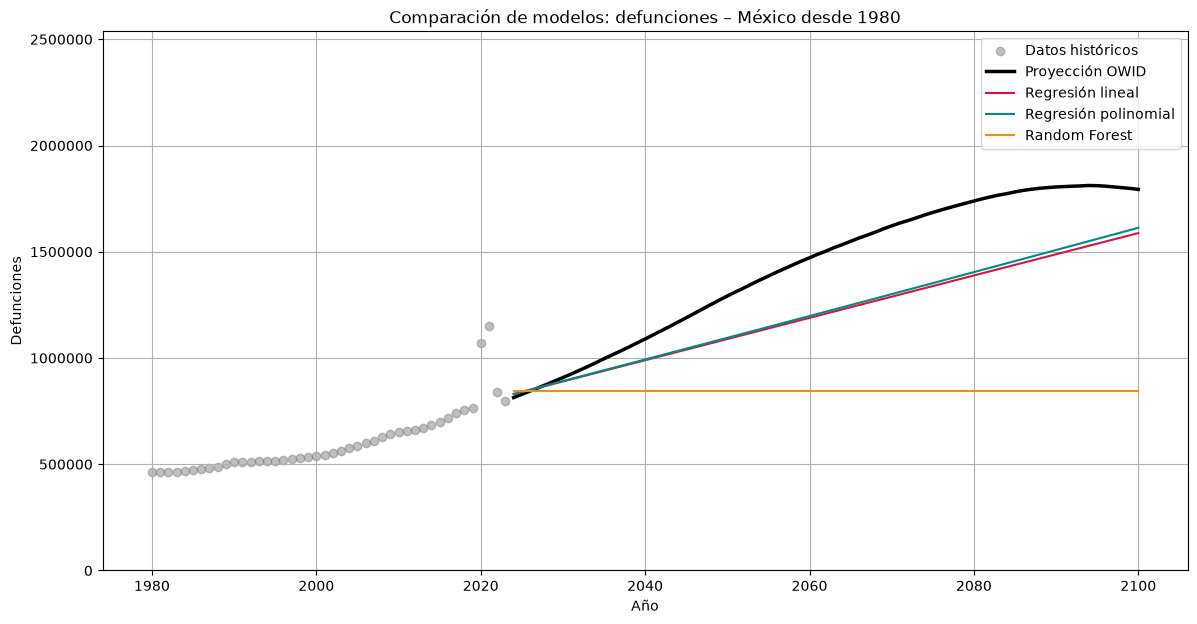

In [110]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_mx80["Year"], y_def_mx80, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_mx80["Year"], proyectado_mx80["deaths"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_def_mx80, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_def_mx80, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_def_mx80, color="darkorange", label="Random Forest")

limite = max(y_def_mx80.max(), proyectado_mx80["deaths"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: defunciones – México desde 1980")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

---
# EJERCICIO 3. México: nacimientos / defunciones a partir de 2000

## 3.1 Extracción

In [111]:
pais = "Mexico"

df_mx00 = df[(df["Entity"] == pais) & (df["Year"] >= 2000)]

df_mx00.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22851,Mexico,MEX,2000,540567.0,NaN,2385977.0,NaN,2385977.0,540567.0
22852,Mexico,MEX,2001,543803.0,NaN,2380261.0,NaN,2380261.0,543803.0
22853,Mexico,MEX,2002,553391.0,NaN,2374140.0,NaN,2374140.0,553391.0
22854,Mexico,MEX,2003,563140.0,NaN,2351177.0,NaN,2351177.0,563140.0
22855,Mexico,MEX,2004,575925.0,NaN,2335226.0,NaN,2335226.0,575925.0


In [112]:
print("Rango de años:", df_mx00["Year"].min(), "-", df_mx00["Year"].max())
print("Número de filas:", df_mx00.shape[0])

Rango de años: 2000 - 2100
Número de filas: 101


## 3.2 Exploración visual

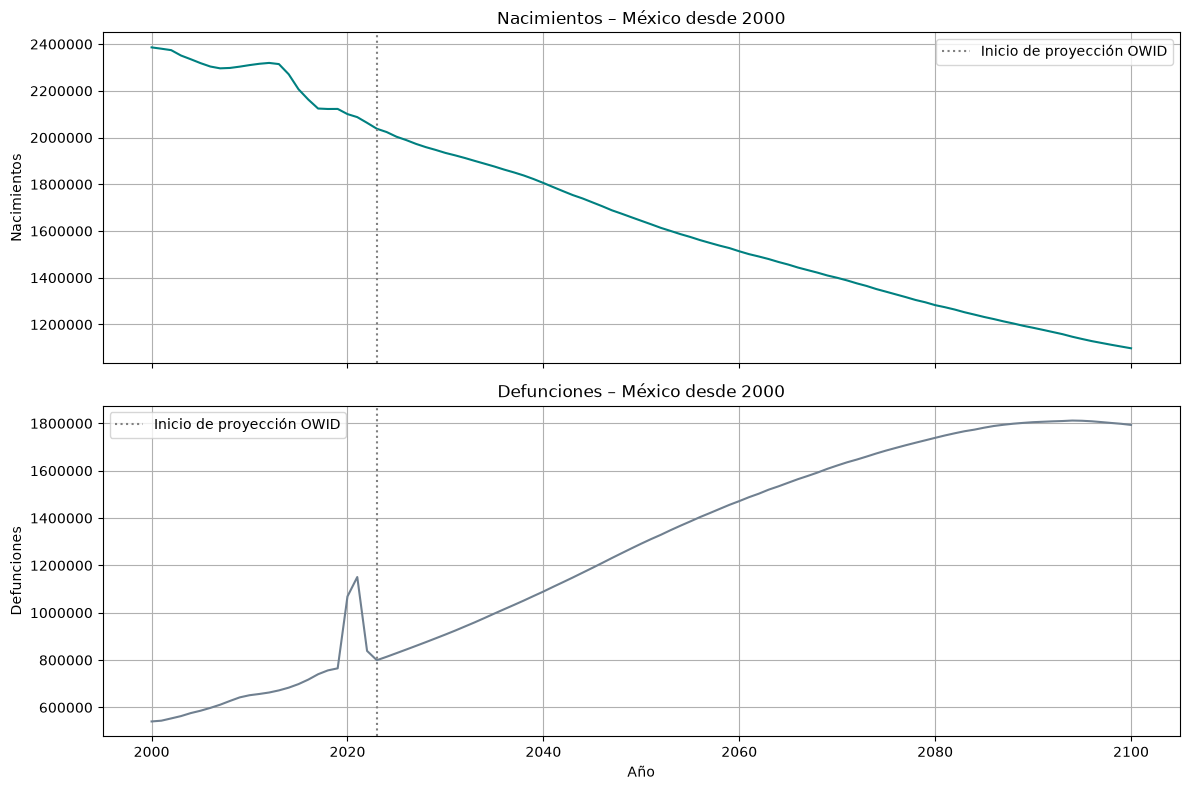

In [113]:
fig, ejes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ejes[0].plot(df_mx00["Year"], df_mx00["births"], color="teal")
ejes[0].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[0].set_title("Nacimientos – México desde 2000")
ejes[0].set_ylabel("Nacimientos")
ejes[0].legend()
ejes[0].grid()

ejes[1].plot(df_mx00["Year"], df_mx00["deaths"], color="slategray")
ejes[1].axvline(2023, color="gray", linestyle=":", label="Inicio de proyección OWID")
ejes[1].set_title("Defunciones – México desde 2000")
ejes[1].set_xlabel("Año")
ejes[1].set_ylabel("Defunciones")
ejes[1].legend()
ejes[1].grid()

for eje in ejes:
    eje.ticklabel_format(style="plain", axis="y", useOffset=False)

plt.tight_layout()
plt.show()

## 3.3 Separar datos históricos (≤ 2023) y proyectados (> 2023)

In [114]:
historico_mx00 = df_mx00[df_mx00["Year"] <= 2023]
proyectado_mx00 = df_mx00[df_mx00["Year"] > 2023]

print("Histórico  ->", historico_mx00.shape, "| años:", historico_mx00["Year"].min(), "a", historico_mx00["Year"].max())
print("Proyectado ->", proyectado_mx00.shape, "| años:", proyectado_mx00["Year"].min(), "a", proyectado_mx00["Year"].max())

Histórico  -> (24, 9) | años: 2000 a 2023
Proyectado -> (77, 9) | años: 2024 a 2100


## 3.4 Variables X e y

In [115]:
X_mx00 = historico_mx00[["Year"]]
y_nac_mx00 = historico_mx00["births"]
y_def_mx00 = historico_mx00["deaths"]

print("X:", X_mx00.shape, "| y:", y_nac_mx00.shape)

X: (24, 1) | y: (24,)


## 3.5 Modelos para **nacimientos**

### Regresión lineal

In [116]:
rl_nac_mx00 = LinearRegression()
rl_nac_mx00.fit(X_mx00, y_nac_mx00)

print("Pendiente (a):", rl_nac_mx00.coef_[0])
print("Intercepto (b):", rl_nac_mx00.intercept_)

pred_rl_nac_mx00 = rl_nac_mx00.predict(X_mx00)
fut_rl_nac_mx00 = rl_nac_mx00.predict(X_futuro)

Pendiente (a): -14819.746956521736
Intercepto (b): 32055962.503043473


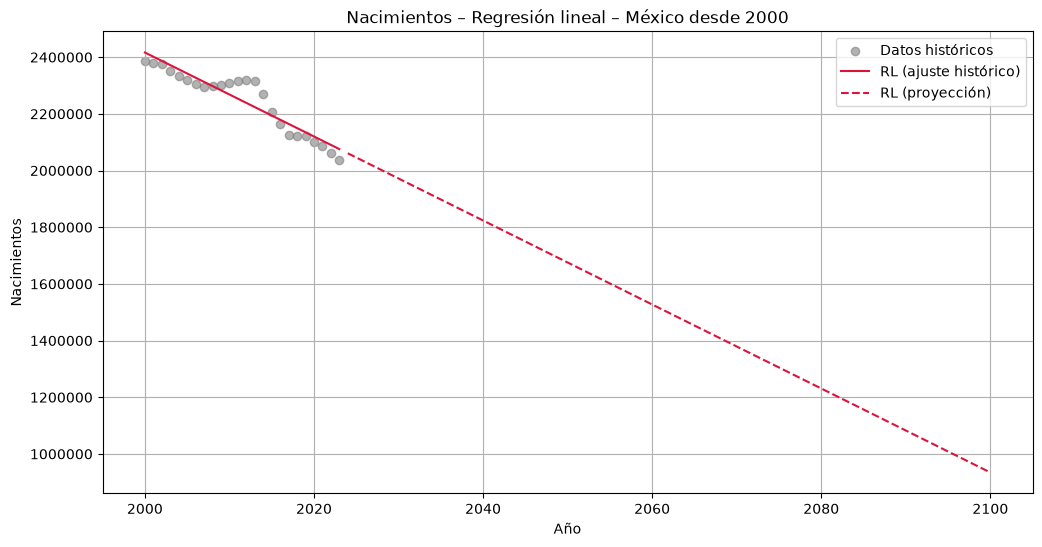

In [117]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_nac_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rl_nac_mx00, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_nac_mx00, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Nacimientos – Regresión lineal – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [118]:
poly_nac_mx00 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_nac_mx00 = poly_nac_mx00.fit_transform(X_mx00)

rp_nac_mx00 = LinearRegression()
rp_nac_mx00.fit(X_poly_nac_mx00, y_nac_mx00)

pred_rp_nac_mx00 = rp_nac_mx00.predict(X_poly_nac_mx00)
fut_rp_nac_mx00 = rp_nac_mx00.predict(poly_nac_mx00.transform(X_futuro))

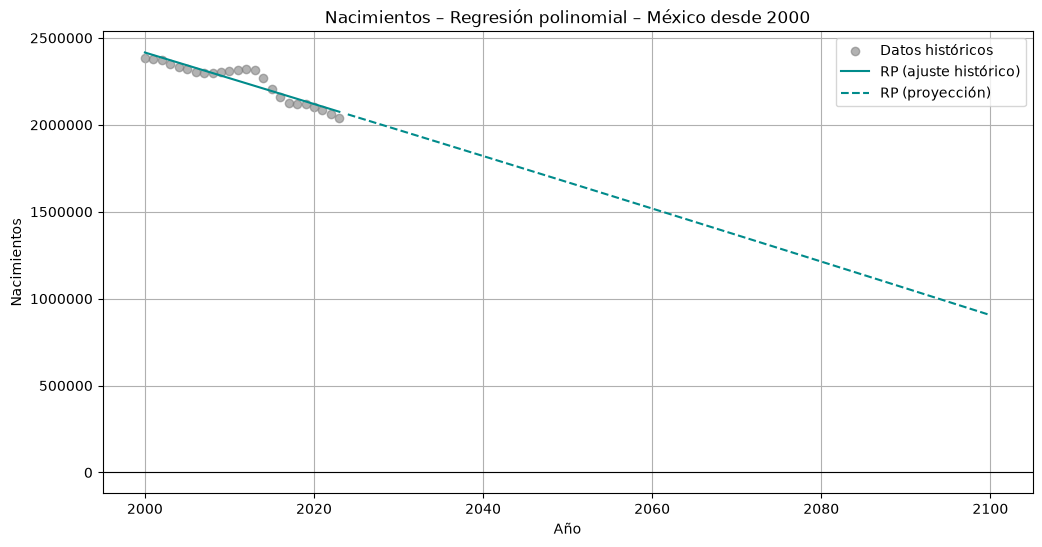

In [119]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_nac_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rp_nac_mx00, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_nac_mx00, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Nacimientos – Regresión polinomial – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [120]:
rf_nac_mx00 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_nac_mx00.fit(X_mx00, y_nac_mx00)

pred_rf_nac_mx00 = rf_nac_mx00.predict(X_mx00)
fut_rf_nac_mx00 = rf_nac_mx00.predict(X_futuro)

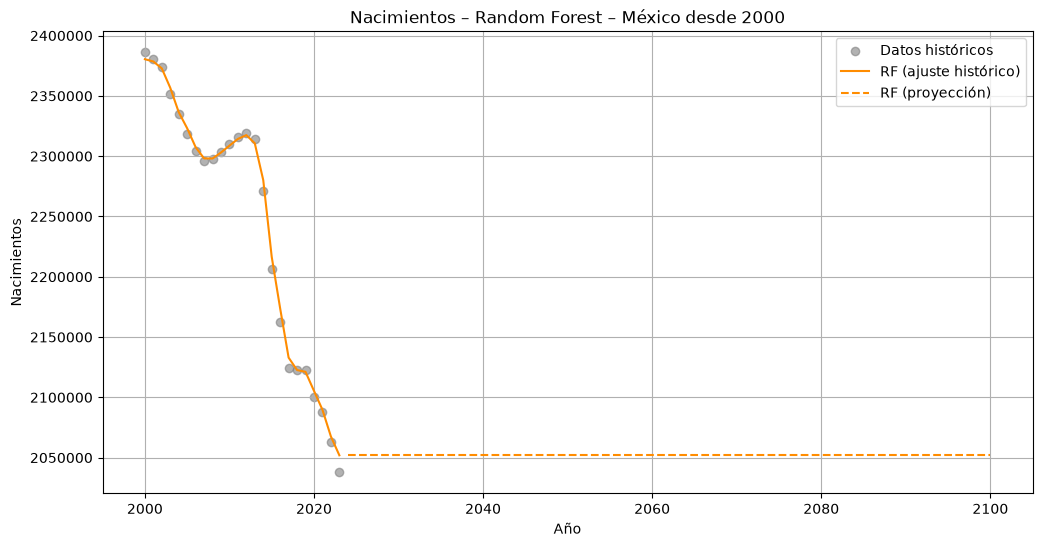

In [121]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_nac_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rf_nac_mx00, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_nac_mx00, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Nacimientos – Random Forest – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (nacimientos)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

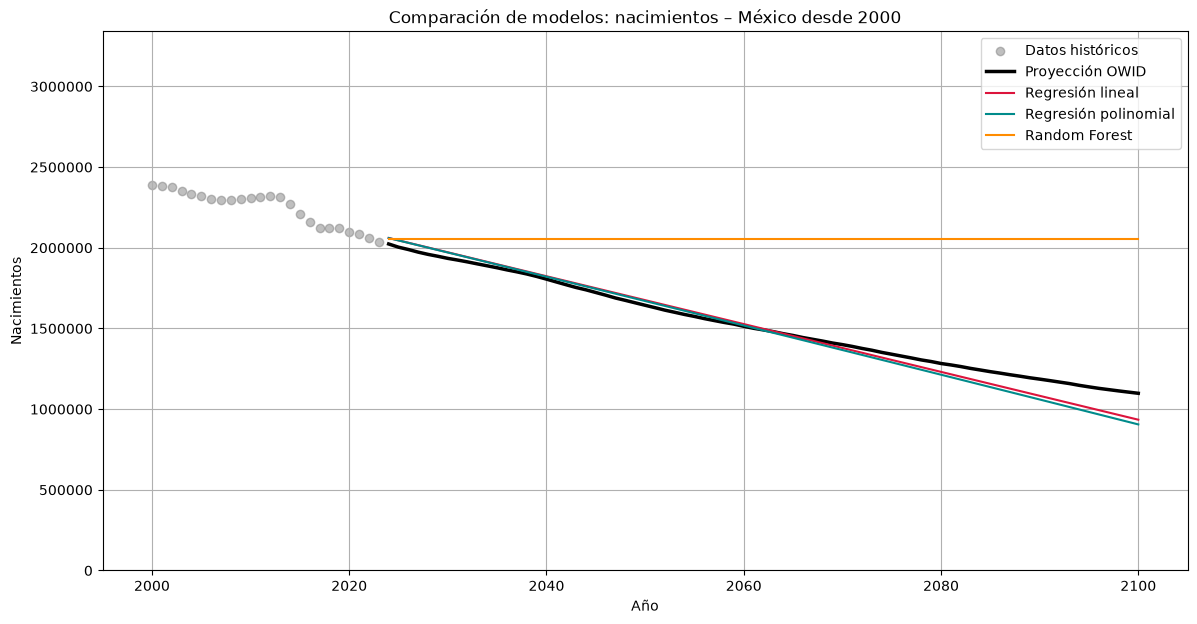

In [122]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_mx00["Year"], y_nac_mx00, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_mx00["Year"], proyectado_mx00["births"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_nac_mx00, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_nac_mx00, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_nac_mx00, color="darkorange", label="Random Forest")

limite = max(y_nac_mx00.max(), proyectado_mx00["births"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: nacimientos – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 3.6 Modelos para **defunciones**

### Regresión lineal

In [123]:
rl_def_mx00 = LinearRegression()
rl_def_mx00.fit(X_mx00, y_def_mx00)

print("Pendiente (a):", rl_def_mx00.coef_[0])
print("Intercepto (b):", rl_def_mx00.intercept_)

pred_rl_def_mx00 = rl_def_mx00.predict(X_mx00)
fut_rl_def_mx00 = rl_def_mx00.predict(X_futuro)

Pendiente (a): 17578.816521739132
Intercepto (b): -34663868.933478266


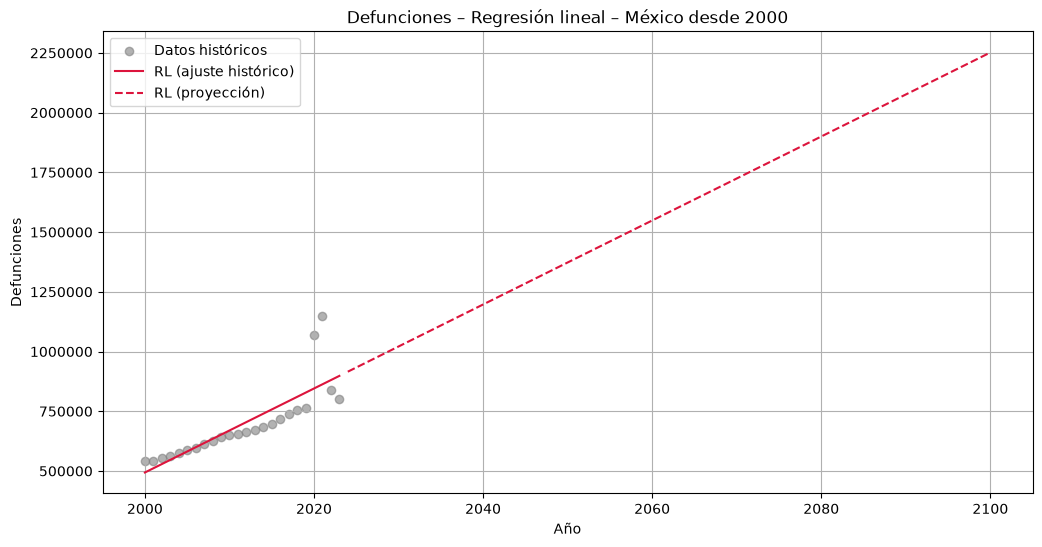

In [124]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_def_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rl_def_mx00, color="crimson", label="RL (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rl_def_mx00, color="crimson", linestyle="--", label="RL (proyección)")
plt.title("Defunciones – Regresión lineal – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Regresión polinomial (grado 2)

In [125]:
poly_def_mx00 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_def_mx00 = poly_def_mx00.fit_transform(X_mx00)

rp_def_mx00 = LinearRegression()
rp_def_mx00.fit(X_poly_def_mx00, y_def_mx00)

pred_rp_def_mx00 = rp_def_mx00.predict(X_poly_def_mx00)
fut_rp_def_mx00 = rp_def_mx00.predict(poly_def_mx00.transform(X_futuro))

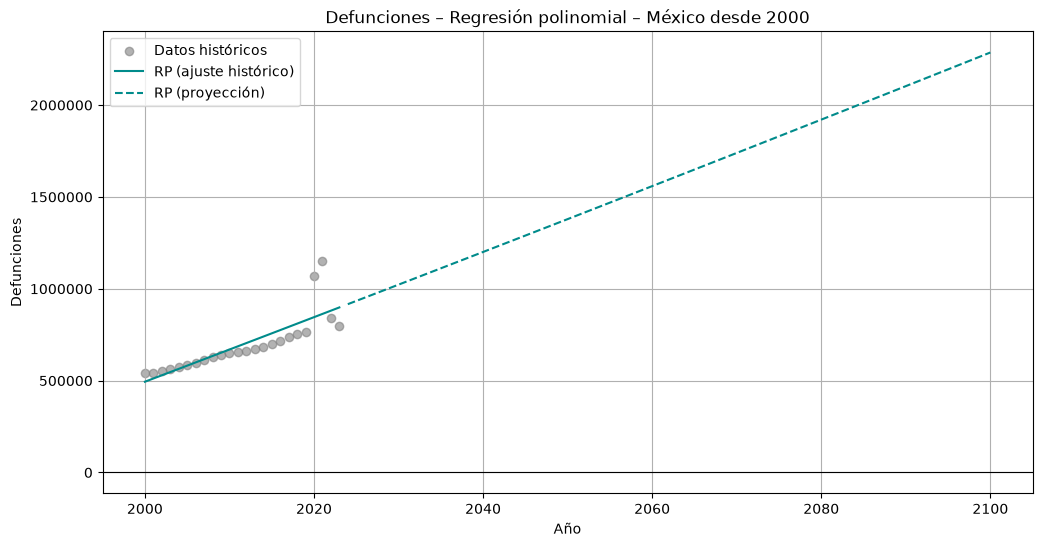

In [126]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_def_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rp_def_mx00, color="darkcyan", label="RP (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rp_def_mx00, color="darkcyan", linestyle="--", label="RP (proyección)")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Defunciones – Regresión polinomial – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Random Forest

In [127]:
rf_def_mx00 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_def_mx00.fit(X_mx00, y_def_mx00)

pred_rf_def_mx00 = rf_def_mx00.predict(X_mx00)
fut_rf_def_mx00 = rf_def_mx00.predict(X_futuro)

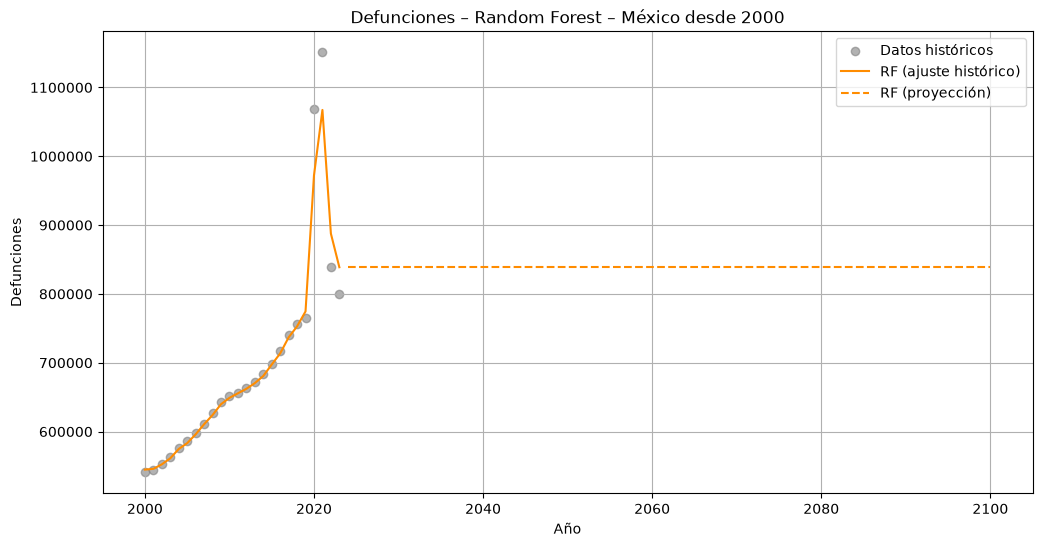

In [128]:
plt.figure(figsize=(12, 6))
plt.scatter(historico_mx00["Year"], y_def_mx00, color="gray", alpha=0.6, label="Datos históricos")
plt.plot(historico_mx00["Year"], pred_rf_def_mx00, color="darkorange", label="RF (ajuste histórico)")
plt.plot(anios_futuros.flatten(), fut_rf_def_mx00, color="darkorange", linestyle="--", label="RF (proyección)")
plt.title("Defunciones – Random Forest – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### Comparación de los 3 modelos vs proyección OWID (defunciones)

Se limita el eje vertical con `plt.ylim` porque la regresión polinomial genera valores muy extremos.

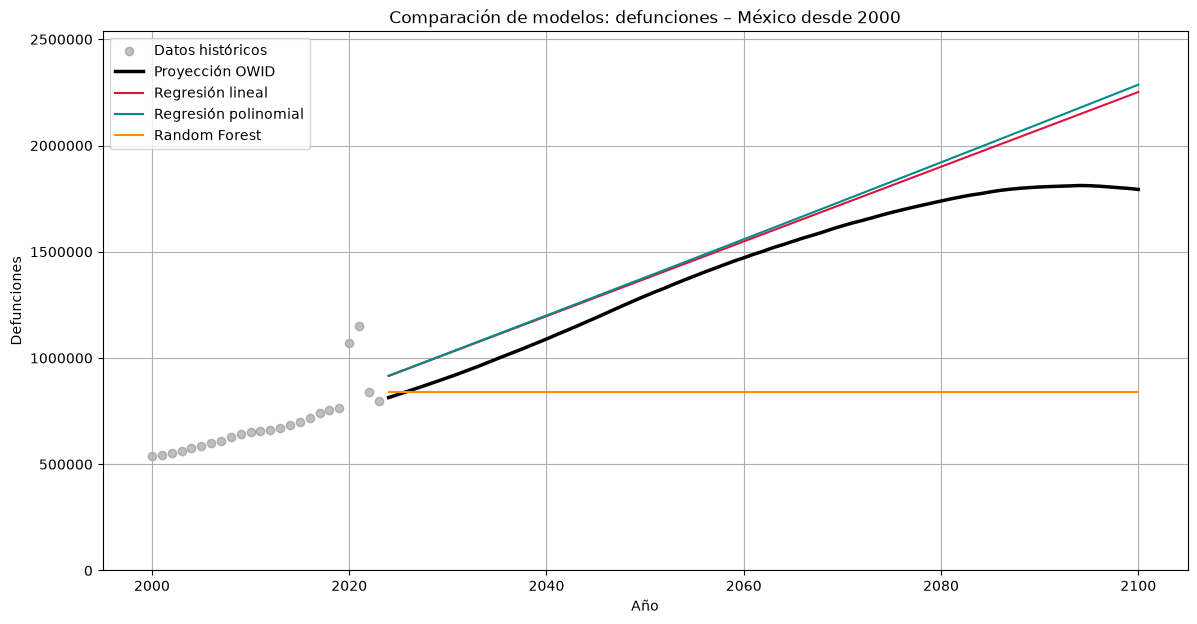

In [129]:
plt.figure(figsize=(14, 7))
plt.scatter(historico_mx00["Year"], y_def_mx00, color="gray", alpha=0.5, label="Datos históricos")
plt.plot(proyectado_mx00["Year"], proyectado_mx00["deaths"], color="black", linewidth=2.5, label="Proyección OWID")
plt.plot(anios_futuros.flatten(), fut_rl_def_mx00, color="crimson", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), fut_rp_def_mx00, color="darkcyan", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), fut_rf_def_mx00, color="darkorange", label="Random Forest")

limite = max(y_def_mx00.max(), proyectado_mx00["deaths"].max()) * 1.4
plt.ylim(0, limite)

plt.title("Comparación de modelos: defunciones – México desde 2000")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()